# Препроцессинг данных
[Открыть EDA](EDA.ipynb)

создание FamilySize;
Title extraction;
FareLog;
обработка пропусков;
encoding;
scaling;
итоговый train_data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent  / "src"))

import importlib

from matplotlib.colors import LinearSegmentedColormap
import preprocessing as preprocessing

In [2]:
#importlib.reload(preprocessing)

In [3]:
COLOR1 = "#069AF3"
COLOR2 = "#FC5A50"
COLOR3 = "#AAFF32"
COLOR4 = "#000080"

custom_cmap = LinearSegmentedColormap.from_list(
    'my_cmap',
    [COLOR1, COLOR2]
)

In [4]:
test_data = pd.read_csv("../data/test.csv")
train_data= pd.read_csv("../data/train.csv")

### Age
Обратим внимание на имена пассажиров- в них присуствуют гоноративы "Mr.","Mrs.",  
"Miss.", "Master.", ...
Спарсим присуствие этих частиц в имени с помощью регулярок.

In [5]:
train_data["Name"].head(5)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

In [6]:
preprocessing.extract_and_set_honorifics(train_data) 

pd.crosstab(train_data.Honorific,train_data.Sex).T.style.background_gradient(cmap=custom_cmap)

Honorific,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


Заменим редкие частицы

In [7]:
preprocessing.normalize_honorifics(train_data)
train_data.groupby('Honorific')['Age'].mean()

Honorific
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

Заполним недостающие возрасты по среднему значению

In [8]:
preprocessing.fill_age_by_honorifics(train_data)
train_data.Age.isnull().any() 

np.False_

### FamilySize, IsAlone
Создадим новые признаки - размер семьи (SibSp + Parch + 1)  
и "пассажир без родственников" (FamilySize ==0)

<Axes: xlabel='IsAlone', ylabel='Survived'>

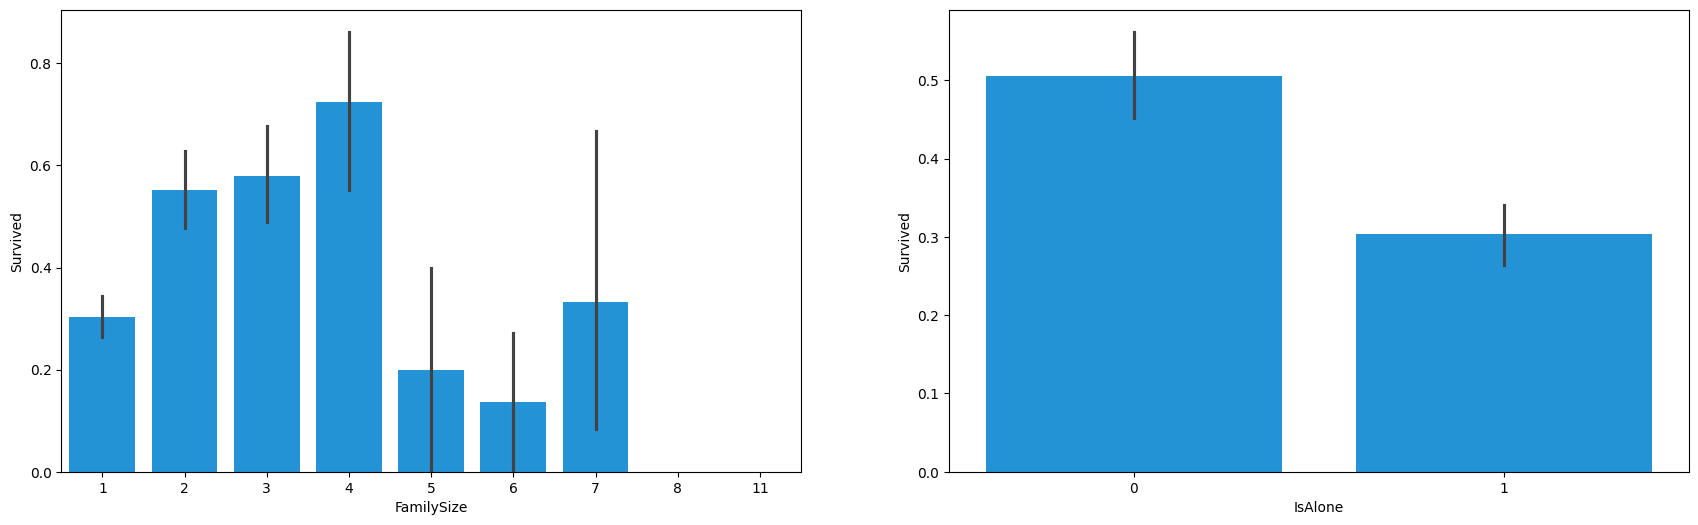

In [9]:
preprocessing.create_FamilySize(train_data)
preprocessing.create_IsAlone(train_data)
fig, ax = plt.subplots(1, 2, figsize=(21, 6))

sns.barplot(data=train_data, x="FamilySize", y="Survived", color= COLOR1, ax=ax[0])
sns.barplot(data=train_data, x="IsAlone", y="Survived", color= COLOR1, ax=ax[1])


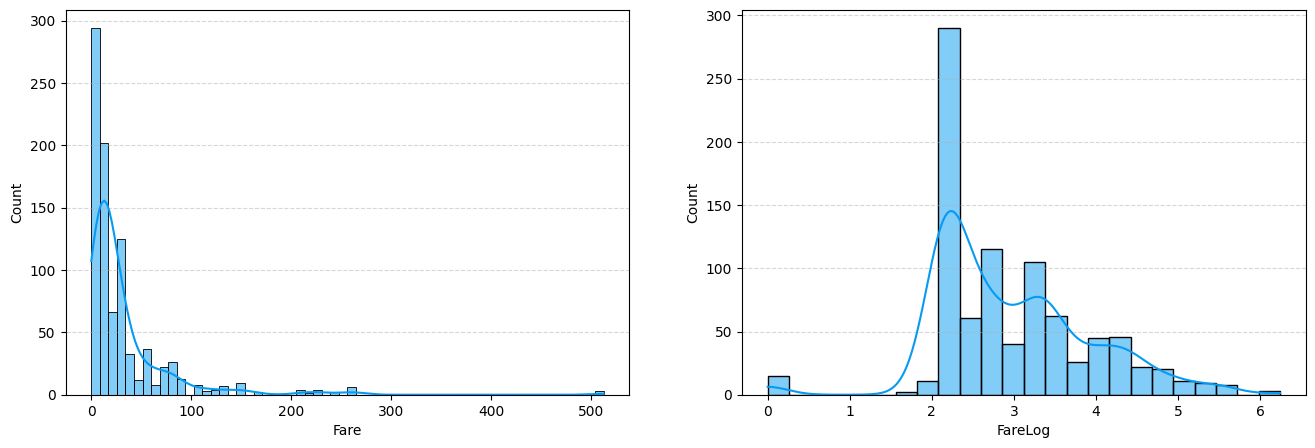

In [10]:
preprocessing.create_FareLog(train_data)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(
        train_data["FareLog"],
        kde=True, ax=ax[1],color=COLOR1
)
sns.histplot(
        train_data["Fare"],
        kde=True, ax=ax[0],color=COLOR1
)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

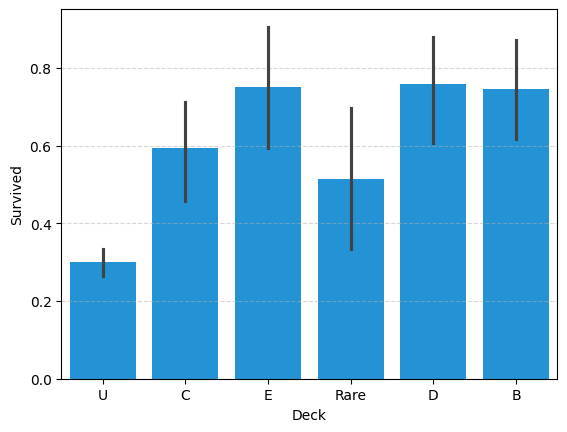

In [11]:
preprocessing.preprocess_Deck(train_data)
sns.barplot(data=train_data, x="Deck", y="Survived", color= COLOR1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

### Scaling и Encoding
Мы не делаем `RobustScaler` и `pd.get_dummies` (OHE) на этапе базового препроцессинга, чтобы избежать утечек данных и ошибок с выравниванием колонок. 
Эти шаги теперь выполняются динамически "на лету" внутри `Pipeline` + `ColumnTransformer` (файл `model.py`). 
Поэтому здесь мы оставляем числовые признаки и категории как есть.

### Удалим столбцы

In [ ]:
preprocessing.drop_features(train_data)
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FareLog,Deck
0,0,3,male,22.0,1,0,7.2500,2,0,2.110213,U
1,1,1,female,38.0,1,0,71.2833,2,0,4.280593,C
2,1,3,female,26.0,0,0,7.9250,1,1,2.188856,U
3,1,1,female,35.0,1,0,53.1000,2,0,3.990834,C
4,0,3,male,35.0,0,0,8.0500,1,1,2.202765,U
